![logo](../../images/logo_diive1_128px.png)

# **Hexbin Plot**

---
**Notebook version**: `1` (29 Mar 2026)  </br>
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

</br>

# **General usage**

```python
import diive as dv
dv.hexbinplot(x=..., y=..., z=...)
```

</br>

# **Description**

- Visualizes relationships between two driver variables and a flux variable using 2D hexagonal binning.
- Unlike `HeatmapXYZ` which requires pre-aggregated data, `HexbinPlot` accepts raw, unaggregated time series and aggregates on-the-fly using matplotlib's hexbin.
- Useful for high-frequency or high-volume data where traditional scatter plots become too dense to interpret.
- Supports optional percentile-based normalization of driver axes (0-100 scale) for comparing variables with different units.
- Configurable aggregation functions (default: median) allow visualizing different properties (mean, std, sum, etc.) within each hexagon.
- This example uses 10 years of growing-season (May–Sep) eddy covariance data: air temperature (TA) and vapor pressure deficit (VPD) as drivers, and net ecosystem exchange (NEE) as the flux variable.
- `dv.hexbinplot()` is an alias for the class `diive.core.plotting.hexbin_plot.HexbinPlot`, which is based on class `diive.core.plotting.heatmap_base.HeatmapBase`.

</br>

# **Imports**

In [1]:
import importlib.metadata
import warnings
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

import diive as dv

warnings.simplefilter("ignore", UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.91.0


</br>

# **Docstring**

In [2]:
# help(dv.hexbinplot)  # Accepts parameters for HeatmapBase

</br>

# **Load and prepare example data**

In [3]:
# Column names in the example dataset
ta_col = 'Tair_f'      # Air temperature (°C)
vpd_col = 'VPD_f'      # Vapor pressure deficit (hPa)
nee_col = 'NEE_CUT_REF_f'  # Net ecosystem exchange (µmol CO₂ m⁻² s⁻¹)

# Which columns go to which axis
xcol = ta_col   # x-axis: air temperature
ycol = vpd_col  # y-axis: vapor pressure deficit
zcol = nee_col  # colour: net ecosystem exchange

# Load example data
df_orig = dv.load_exampledata_parquet()

# Subset to growing season (May–Sep)
df_orig = df_orig.loc[(df_orig.index.month >= 5) & (df_orig.index.month <= 9)].copy()

# Select and prepare relevant columns
df = df_orig[[xcol, ycol, zcol]].copy()
df = df.dropna()

print(f"Data shape: {df.shape}")
print(f"Time period: {df.index[0]} to {df.index[-1]}")
df.head()

Loaded .parquet file F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\configs\exampledata\exampledata_PARQUET_CH-DAV_FP2022.5_2013-2022_ID20230206154316_30MIN.parquet (0.044 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Data shape: (73440, 3)
Time period: 2013-05-01 00:15:00 to 2022-09-30 23:45:00


,Tair_f,VPD_f,NEE_CUT_REF_f
TIMESTAMP_MIDDLE,,,
2013-05-01 00:15:00,6.367,1.868,4.892
2013-05-01 00:45:00,6.800,2.109,5.343
2013-05-01 01:15:00,6.167,1.710,5.143
2013-05-01 01:45:00,6.100,1.887,5.177
2013-05-01 02:15:00,5.700,1.783,5.020


</br>

# Example (1): Minimal approach with percentile normalization
- The simplest approach with percentile-normalized driver axes
- Uses automatic axis label inference from column names

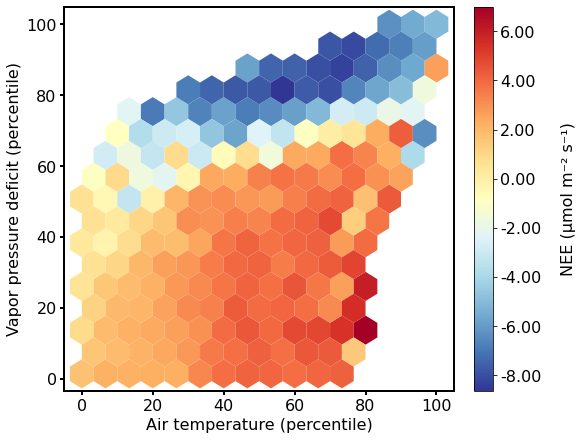

In [4]:
hm = dv.hexbinplot(
    x=df[xcol],
    y=df[ycol],
    z=df[zcol],
    normalize_axes=True,  # Convert drivers to 0-100 percentile scale
    gridsize=15,
    mincnt=5,  # Filter sparse bins to avoid warnings
    xlabel='Air temperature (percentile)',
    ylabel='Vapor pressure deficit (percentile)',
    zlabel='NEE (µmol m⁻² s⁻¹)',
    cmap='RdYlBu_r',
    figsize=(8, 6)
)
hm.show()

</br>

# Example (2): Absolute values with custom styling
- Uses original (absolute) values instead of percentiles
- Demonstrates custom colormap, gridsize, and aggregation function

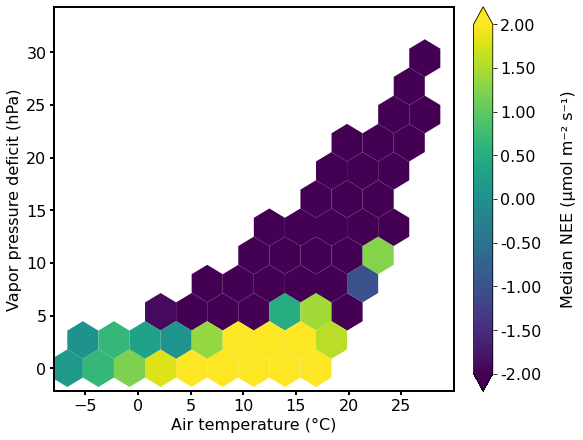

In [5]:
hm = dv.hexbinplot(
    x=df[xcol],
    y=df[ycol],
    z=df[zcol],
    normalize_axes=False,  # Use original values
    gridsize=12,
    reduce_C_function=np.median,  # Aggregate with median (default)
    mincnt=5,  # Filter sparse bins
    xlabel='Air temperature (°C)',
    ylabel='Vapor pressure deficit (hPa)',
    zlabel='Median NEE (µmol m⁻² s⁻¹)',
    cmap='viridis',
    vmin=-2,
    vmax=2,
    figsize=(8, 6)
)
hm.show()

</br>

# Example (3): Mean aggregation instead of median
- Demonstrates the effect of different aggregation functions
- Compare with Example (2) to see how median vs. mean affect the visualization

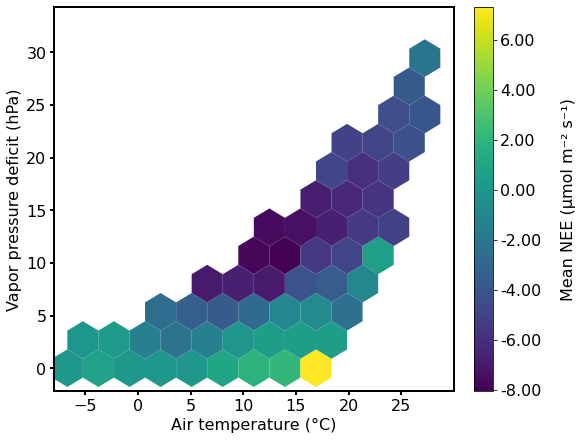

In [6]:
hm = dv.hexbinplot(
    x=df[xcol],
    y=df[ycol],
    z=df[zcol],
    normalize_axes=False,
    gridsize=12,
    reduce_C_function=np.mean,  # Use mean instead of median
    mincnt=5,  # Filter sparse bins to avoid warnings
    xlabel='Air temperature (°C)',
    ylabel='Vapor pressure deficit (hPa)',
    zlabel='Mean NEE (µmol m⁻² s⁻¹)',
    cmap='viridis',
    figsize=(8, 6)
)
hm.show()

</br>

# Example (4): Visualizing variability with standard deviation
- Shows NEE variability (standard deviation) instead of central tendency
- Useful for understanding uncertainty or volatility in different conditions

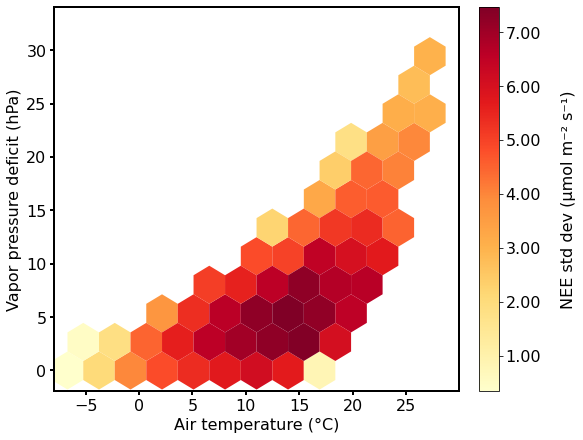

In [7]:
hm = dv.hexbinplot(
    x=df[xcol],
    y=df[ycol],
    z=df[zcol],
    normalize_axes=False,
    gridsize=12,
    reduce_C_function=np.std,  # Show standard deviation
    mincnt=5,  # Filter sparse bins to avoid warnings
    xlabel='Air temperature (°C)',
    ylabel='Vapor pressure deficit (hPa)',
    zlabel='NEE std dev (µmol m⁻² s⁻¹)',
    cmap='YlOrRd',
    figsize=(8, 6)
)
hm.show()

</br>

# Example (5): Side-by-side comparison of percentile vs absolute
- Demonstrates the effect of percentile normalization
- Left: absolute values with original axis ranges
- Right: percentile-normalized axes with equal spacing

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Absolute values
hm_abs = dv.hexbinplot(
    ax=ax1,
    x=df[xcol],
    y=df[ycol],
    z=df[zcol],
    normalize_axes=False,
    gridsize=12,
    mincnt=5,
    xlabel='Air temperature (°C)',
    ylabel='Vapor pressure deficit (hPa)',
    zlabel='NEE (µmol m⁻² s⁻¹)',
    cmap='RdYlBu_r'
)
hm_abs.plot()
ax1.set_title('Absolute Values', fontsize=12, fontweight='bold')

# Percentile normalized
hm_pct = dv.hexbinplot(
    ax=ax2,
    x=df[xcol],
    y=df[ycol],
    z=df[zcol],
    normalize_axes=True,
    gridsize=12,
    mincnt=5,
    xlabel='Air temperature (percentile)',
    ylabel='Vapor pressure deficit (percentile)',
    zlabel='NEE (µmol m⁻² s⁻¹)',
    cmap='RdYlBu_r'
)
hm_pct.plot()
ax2.set_title('Percentile Normalized', fontsize=12, fontweight='bold')

fig.suptitle('Effect of Percentile Normalization on Hexbin Visualization', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.show()

</br>

# **Key Parameters**

### Core Parameters
- **x, y, z**: pandas Series with driver variables (x, y) and flux values (z)
- **normalize_axes**: Boolean, convert x/y to 0-100 percentile scale (default: False)
- **gridsize**: Number of hexagon bins (default: 11, larger = more detailed bins)
- **reduce_C_function**: Aggregation function for z-values within bins (default: np.median)
- **mincnt**: Minimum number of data points per hexagon (default: 0, recommended: 5+ to avoid warnings)

### Customization Parameters
- **xlabel, ylabel, zlabel**: Axis labels (auto-inferred from Series.name if not provided)
- **title**: Plot title
- **figsize**: Figure size as (width, height) in inches
- **cmap**: Matplotlib colormap name (e.g., 'viridis', 'RdYlBu_r', 'YlOrRd')
- **vmin, vmax**: Color scale limits (optional)
- **cb_digits_after_comma**: Decimal places for colorbar labels (default: 2)

### Advanced Parameters
- **edgecolors**: Hexagon edge color (default: 'none')

</br>

# **End of notebook**

In [9]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-03-30 02:23:53
